In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU is not enabled. Go to Runtime > Change runtime type > T4 GPU."
    )

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers accelerate scikit-learn pandas matplotlib seaborn

In [3]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [5]:
from google.colab import files

uploaded = files.upload()

Saving phishing_legit_dataset_KD_10000.csv to phishing_legit_dataset_KD_10000.csv


In [7]:


df = pd.read_csv("phishing_legit_dataset_KD_10000.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (10000, 5)

Columns:
['text', 'label', 'phishing_type', 'severity', 'confidence']


,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


In [8]:
df = df[["text", "label"]].copy()

print("Columns used for classification:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["label"].value_counts())

Columns used for classification:
['text', 'label']

Class distribution:
label
1    6000
0    4000
Name: count, dtype: int64


In [9]:
def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " URL ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " EMAIL ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["text"] = df["text"].apply(clean_text)

# Remove missing/empty emails
df = df.dropna(subset=["text", "label"])
df = df[df["text"].str.len() > 10]

# Ensure labels are integers
df["label"] = df["label"].astype(int)

df = df.reset_index(drop=True)

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (10000, 2)


In [10]:
duplicates = df["text"].duplicated().sum()

print("Duplicate emails found:", duplicates)

df = df.drop_duplicates(
    subset=["text"],
    keep="first"
).reset_index(drop=True)

print("Dataset after duplicate removal:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

Duplicate emails found: 44
Dataset after duplicate removal: (9956, 2)

Class distribution:
label
1    6000
0    3956
Name: count, dtype: int64


In [11]:
X = df["text"]
y = df["label"]

# First: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Second: split temporary 20% into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 7964
Validation samples: 996
Test samples: 996


In [12]:
train_set = set(X_train)
val_set = set(X_val)
test_set = set(X_test)

print("Train-Test overlap:", len(train_set.intersection(test_set)))
print("Train-Validation overlap:", len(train_set.intersection(val_set)))
print("Validation-Test overlap:", len(val_set.intersection(test_set)))

Train-Test overlap: 0
Train-Validation overlap: 0
Validation-Test overlap: 0


In [13]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded.


In [14]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

print("Tokenization completed.")

Tokenization completed.


In [15]:
class EmailDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist() if hasattr(labels, "tolist") else list(labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx], dtype=torch.long)
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)


train_dataset = EmailDataset(train_encodings, y_train)
val_dataset = EmailDataset(val_encodings, y_val)
test_dataset = EmailDataset(test_encodings, y_test)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7964
Validation: 996
Test: 996


In [16]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [17]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print("Device:", device)
print("Model loaded successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device: cuda
Model loaded successfully.


In [18]:
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_training_steps),
    num_training_steps=total_training_steps
)

print("Training configuration:")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Max sequence length:", MAX_LENGTH)

Training configuration:
Epochs: 3
Batch size: 16
Learning rate: 2e-05
Max sequence length: 128


In [19]:
def evaluate_model(model, dataloader):

    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predictions": np.array(all_predictions),
        "labels": np.array(all_labels)
    }


In [20]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

for epoch in range(EPOCHS):

    print("=" * 70)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 70)

    model.train()

    total_train_loss = 0

    for step, batch in enumerate(train_loader):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        if (step + 1) % 100 == 0:
            print(
                f"Step {step + 1}/{len(train_loader)} "
                f"- Loss: {loss.item():.4f}"
            )

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    val_results = evaluate_model(
        model,
        val_loader
    )

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_results["loss"])
    history["val_accuracy"].append(val_results["accuracy"])
    history["val_precision"].append(val_results["precision"])
    history["val_recall"].append(val_results["recall"])
    history["val_f1"].append(val_results["f1"])

    print()
    print(f"Training Loss : {avg_train_loss:.4f}")
    print(f"Validation Loss : {val_results['loss']:.4f}")
    print(f"Validation Accuracy : {val_results['accuracy']:.4f}")
    print(f"Validation Precision : {val_results['precision']:.4f}")
    print(f"Validation Recall : {val_results['recall']:.4f}")
    print(f"Validation F1 : {val_results['f1']:.4f}")

Epoch 1/3
Step 100/498 - Loss: 0.0124
Step 200/498 - Loss: 0.0023
Step 300/498 - Loss: 0.0009
Step 400/498 - Loss: 0.0004

Training Loss : 0.0745
Validation Loss : 0.0002
Validation Accuracy : 1.0000
Validation Precision : 1.0000
Validation Recall : 1.0000
Validation F1 : 1.0000
Epoch 2/3
Step 100/498 - Loss: 0.0003
Step 200/498 - Loss: 0.0002
Step 300/498 - Loss: 0.0001
Step 400/498 - Loss: 0.0001

Training Loss : 0.0002
Validation Loss : 0.0001
Validation Accuracy : 1.0000
Validation Precision : 1.0000
Validation Recall : 1.0000
Validation F1 : 1.0000
Epoch 3/3
Step 100/498 - Loss: 0.0001
Step 200/498 - Loss: 0.0001
Step 300/498 - Loss: 0.0001
Step 400/498 - Loss: 0.0001

Training Loss : 0.0001
Validation Loss : 0.0001
Validation Accuracy : 1.0000
Validation Precision : 1.0000
Validation Recall : 1.0000
Validation F1 : 1.0000


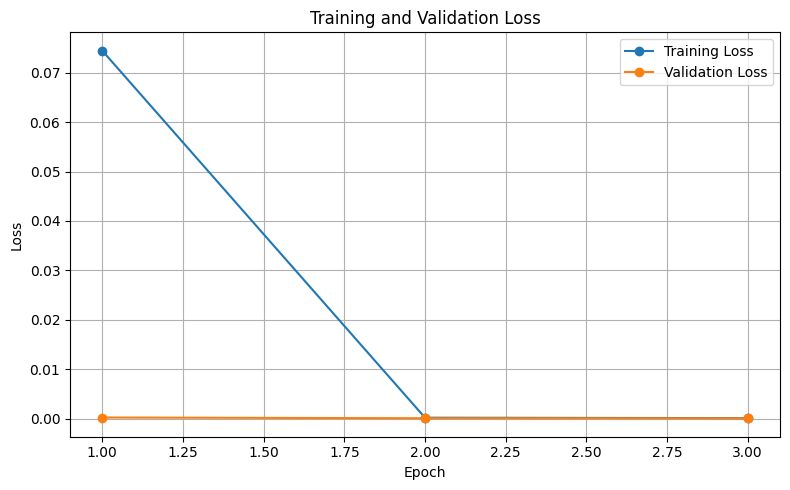

In [21]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

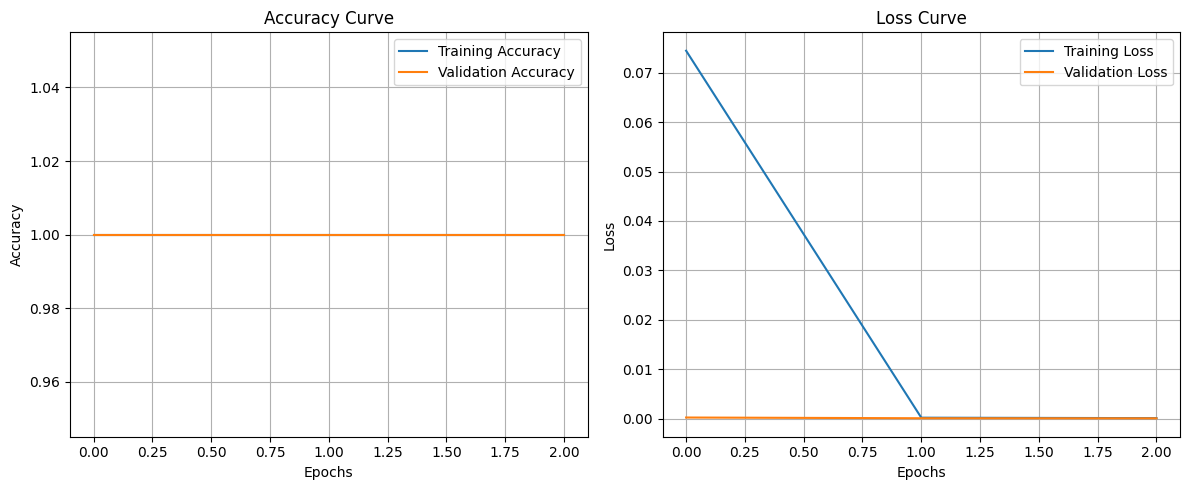

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['val_accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
test_results = evaluate_model(
    model,
    test_loader
)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Loss      : {test_results['loss']:.4f}")
print(f"Accuracy       : {test_results['accuracy']:.4f}")
print(f"Precision      : {test_results['precision']:.4f}")
print(f"Recall         : {test_results['recall']:.4f}")
print(f"F1 Score       : {test_results['f1']:.4f}")

FINAL TEST RESULTS
Test Loss      : 0.0001
Accuracy       : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000


In [24]:
test_predictions = test_results["predictions"]
test_labels = test_results["labels"]

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     1.0000    1.0000    1.0000       396
    Phishing     1.0000    1.0000    1.0000       600

    accuracy                         1.0000       996
   macro avg     1.0000    1.0000    1.0000       996
weighted avg     1.0000    1.0000    1.0000       996



[[396   0]
 [  0 600]]


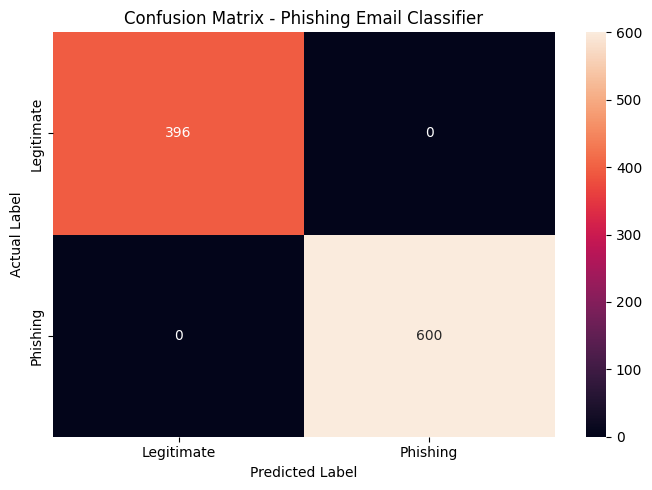

In [25]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Phishing Email Classifier")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
results_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        test_results["accuracy"],
        test_results["precision"],
        test_results["recall"],
        test_results["f1"]
    ]
})

display(results_summary)

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
